# Производство на електроенергия

В тази задача ще разгледаме малък пример за оптимизация на производство на електроенергия с данни от Джорджия, САЩ (2004-2013 г.), събрани в този [Excel файл](./excel/power-plants.xlsx).
В тези данни са описани характеристиките на 10 централи, които използват различни горива (въглища, природен газ, ядрена енергия, биомаса, петрол и хидроенергия) за производство на електроенергия,
както и търсенето на електроенергия за всеки час от 31-те дни на два месеца - един летен месец (юли) и един зимен месец (януари).

Целта ни е да съставим план за производство, който да определя кога и колко електроенергия да произвеждат централите, така че да покрият търсенето на електроенергия и да постигне възможно най-ниски разходи.

![](https://upload.wikimedia.org/wikipedia/commons/thumb/7/73/Kraftwerk_Niederau%C3%9Fem_2006.jpg/1920px-Kraftwerk_Niederau%C3%9Fem_2006.jpg){width=600px}

## Исторически данни за търсенето на електроенергия

Данните за търсене на електроенергия в MWh (колонка `LOAD`) са налични за всеки час от 31-те дни на два месеца - един летен месец (юли) и един зимен месец (януари).

За нашето упражнение можем да изберем _една_ дата, например 1 юли 2011 г., и да използваме само данните за този ден (@fig-electricity-demand).

In [1]:
import pandas as pd   
import matplotlib.pyplot as plt  
import seaborn as sns  
import warnings
warnings.filterwarnings("ignore")

df_load_curves = pd.read_csv('https://github.com/Gurobi/modeling-examples/blob/master/power_generation/demand.csv?raw=true')
# df_load_curves = pd.read_csv('demand.csv')

# Избор на търсенето за избрания ден (1 юли 2011 г.)
df_subset = df_load_curves[(df_load_curves['YEAR']==2011)&(df_load_curves['MONTH']==7)&(df_load_curves['DAY']==1)]

# Записване на търсенето в речник
d = df_subset.set_index(['HOUR']).LOAD.to_dict()

H = set(d.keys()) # Множество от часовете в денонощието (1 до 24)

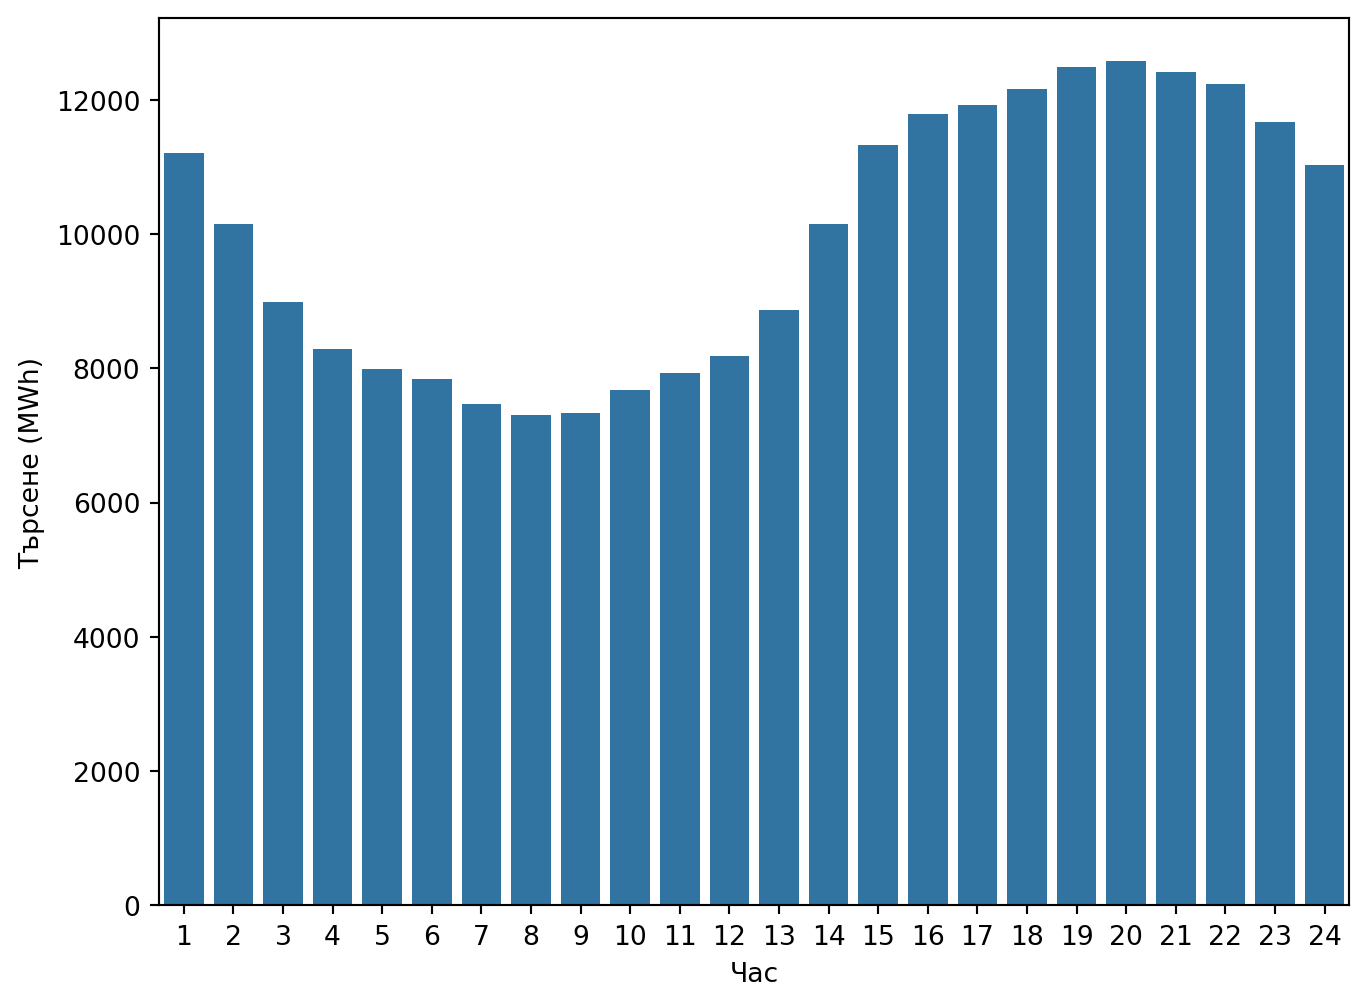

In [2]:
#| label: fig-electricity-demand
#| fig-cap: Търсене на електроенергия на 1 юли 2011 г.

fig, ax = plt.subplots(figsize=(8, 6))
demand_plot = sns.barplot(x=list(range(1,25)), y=[d[h] for h in range(1,25)])
demand_plot.set_xticklabels(demand_plot.get_xticklabels());
demand_plot.set(xlabel='Час', ylabel='Търсене (MWh)');
plt.show()

## Капацитети и ограничения

Електроцентралите се различават според вида на използваното гориво: въглищни, ядрени, нефтени, газови, водноелектрически и на биомаса.

Данните в Excel файла показват и капацитетите (в MWh) само за девет електроцентрали в щата. Десетата въглищна централа е обобщение (мегацентрала с име 'OTHER COAL') на останалите централи в щата (които не показваме тук, за да опростим задачата).

Използваното от всяка централа **гориво** също е дадено в данните. Тази информация е необходима, за да определим някои разходи, зависещи от горивото.

In [3]:
df_plant_info = pd.read_csv('https://github.com/Gurobi/modeling-examples/blob/master/power_generation/small_plant_data/plant_capacities.csv?raw=true') # Заменете "small_plant_data" с "large_plant_data", за да използвате пълния набор от данни
# df_plant_info = pd.read_csv('small_plant_data/plant_capacities.csv')

P = set(df_plant_info['Plant'].unique())                          # Множество от всички електроцентрали

plant_type = df_plant_info.set_index('Plant').PlantType.to_dict() # Тип електроцентрала за всяка централа

P_N = set([i for i in P if plant_type[i]=='NUCLEAR'])             # Множество от всички ядрени централи

fuel_type = df_plant_info.set_index('Plant').FuelType.to_dict()   # Тип гориво за всяка централа


При определянето на производствения план трябва да се съобразим и с капацитетите на централите (@fig-plant-capacity), описани в `Plant Info` (capacity) в MWh. С други думи, производственият план за всяка централа не може да надхвърля нейния капацитет.

Освен максималния капацитет за всяка централа планът трябва да съобрази и минимални производствени граници. Когато са включени, ядрените електроцентрали трябва да работят поне на 80% от максималния си капацитет. При останалите типове централи минималното производство е един процент от максималния капацитет.

В допълнение има изискване за плавност при промяната на производството. При въглищни електроцентрали производството не може да се променя с повече от 25% от максималния капацитет на централата между два последователни часа. При ядрените централи това ограничение е 20%. За всички останали типове централи няма ефективно ограничение на промяната.

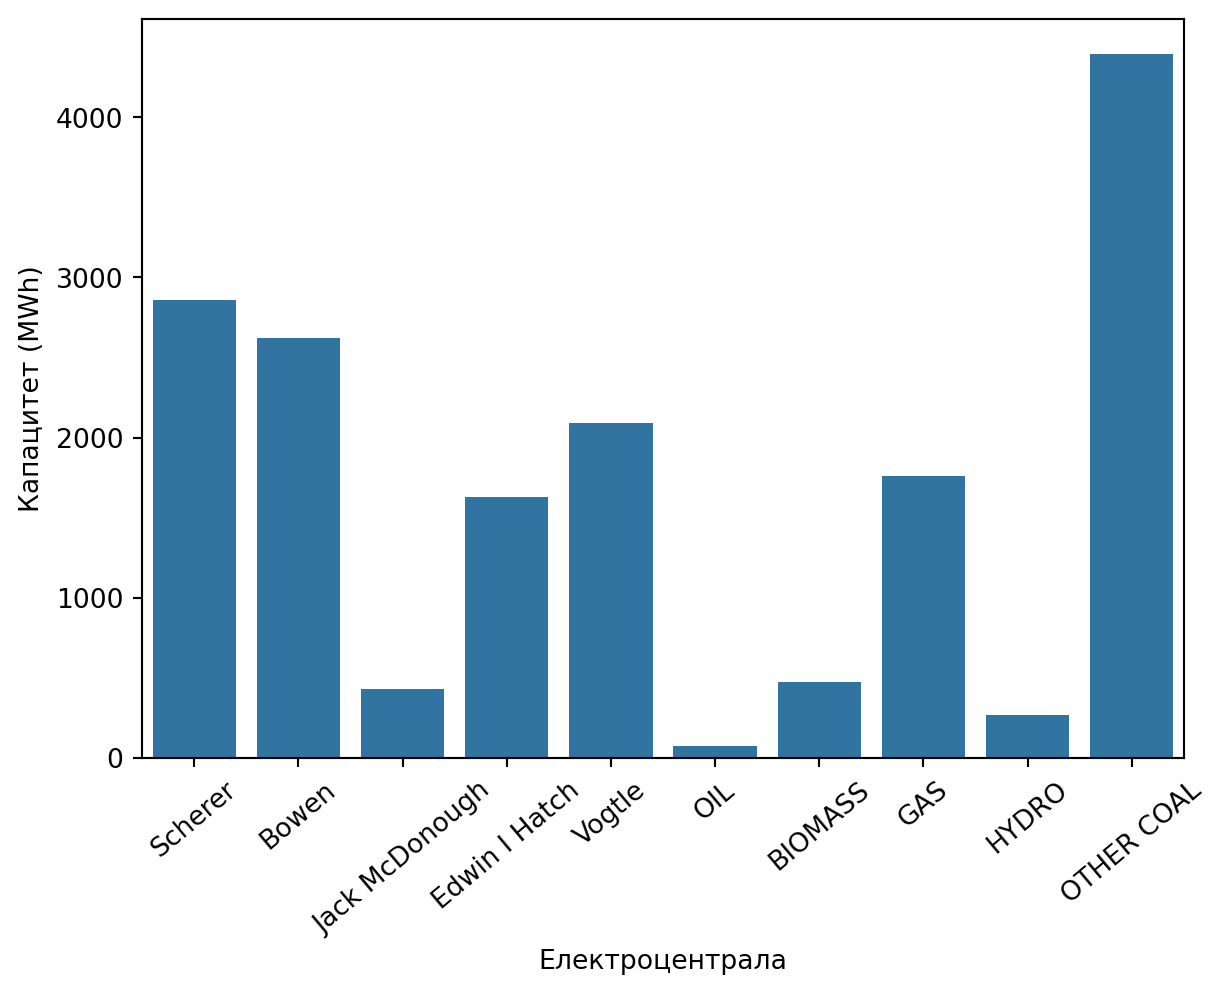

In [4]:
#| label: fig-plant-capacity
#| fig-cap: Капацитет на електроцентралите

df_plant_info['capacity'] = df_plant_info['Capacity']
c = df_plant_info.set_index('Plant').capacity.to_dict() # Производствен капацитет

capacity_plot = sns.barplot(x=list(c.keys()), y=[c[k] for k in c])
capacity_plot.set_xticklabels(capacity_plot.get_xticklabels(), rotation=40);
capacity_plot.set(xlabel='Електроцентрала', ylabel='Капацитет (MWh)');
plt.show()

## Разходи

Разходите за производство на електроенергия се формират от пет компонента: разходи за гориво, експлоатационни разходи, разходи за пускане и спиране, както и здравни разходи.

За тези разходи са налични исторически годишни средни стойности (2004-2011) по тип гориво (`Fuel Costs`, `Operating Costs`, `Startup Costs`).
За целите на настоящата задача ще използваме средните разходи за 2011 г.

Първо разглеждаме **разходите за гориво**, тоест разходите за производство на *един* MWh електроенергия (@fig-electricity-costs), от която виждаме, че въглищата и газът са били най-скъпите горива, докато ядрената енергия е била най-евтината.

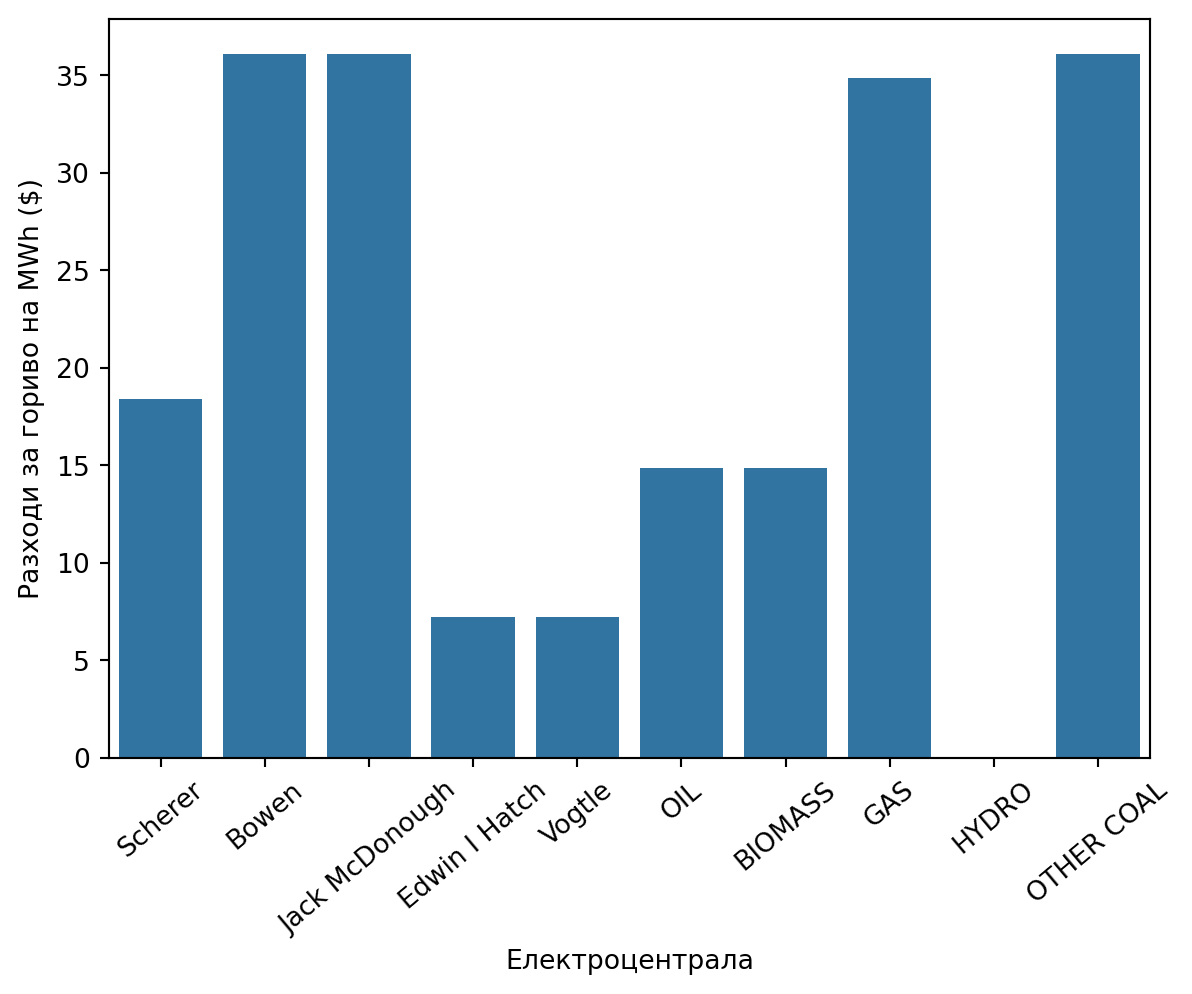

In [5]:
#| label: fig-electricity-costs
#| fig-cap: Разходи за гориво на MWh електроенергия за различните електроцентрали

df_fuel_costs = pd.read_csv('https://github.com/Gurobi/modeling-examples/blob/master/power_generation/small_plant_data/fuel_costs.csv?raw=true')
# df_fuel_costs = pd.read_csv('small_plant_data/fuel_costs.csv')

# Зареждане на разходите за гориво и съпоставяне от тип гориво към име на електроцентрала
f = {i: df_fuel_costs[df_fuel_costs['year']==2011].T.to_dict()[9][fuel_type[i]] for i in fuel_type} # Речник с разходите за гориво по централи

# Визуализация на разходите за гориво
fuelcost_plot = sns.barplot(x=list(f.keys()), y=[f[k] for k in f])
fuelcost_plot.set_xticklabels(fuelcost_plot.get_xticklabels(), rotation=40);
fuelcost_plot.set(xlabel='Електроцентрала', ylabel='Разходи за гориво на MWh ($)');
plt.show()

Вторият вид разходи са **експлоатационните разходи**, тоест разходите на час за работа на включена електроцентрала.

In [6]:
df_oper_costs = pd.read_csv('https://github.com/Gurobi/modeling-examples/blob/master/power_generation/small_plant_data/operating_costs.csv?raw=true')
# df_oper_costs = pd.read_csv('small_plant_data/operating_costs.csv')
o = {i: df_oper_costs[df_oper_costs['year']==2011].T.to_dict()[9][fuel_type[i]] for i in fuel_type} # Експлоатационни разходи/MWh (централа)

Третият и четвъртият вид разходи са разходите за **пускане** и разходите за **спиране**, които са свързани с всяко включване и изключване на електроцентрала. Отчитането на тези разходи в модела води до по-стабилен план за производство на електроенергия. В настоящия вариант на задачата ще приемем, че тези разходи са едни и същи за спиране и за пускане (`Startup Costs`).

In [7]:
df_startup_costs = pd.read_csv('https://github.com/Gurobi/modeling-examples/blob/master/power_generation/small_plant_data/startup_costs.csv?raw=true')
# df_startup_costs = pd.read_csv('small_plant_data/startup_costs.csv')
s = {i: df_startup_costs[df_startup_costs['year']==2011].T.to_dict()[9][fuel_type[i]] for i in fuel_type} # Разходи за пускане/MWh (централа)

t = s.copy() # Допускане: разходите за спиране = разходите за пускане

Последният компонент на разходите е свързан със **здравни последици** от горенето на въглища. Оценки за тези разходи са налични само за трите въглищни централи (Bowen, Jack McDonough и Scherer) и са агрегирани според различни характеристики на околната среда, които зависят от часа на деня. Поради тази причина тези разходи варират по часове (@fig-power-plants-health-costs).

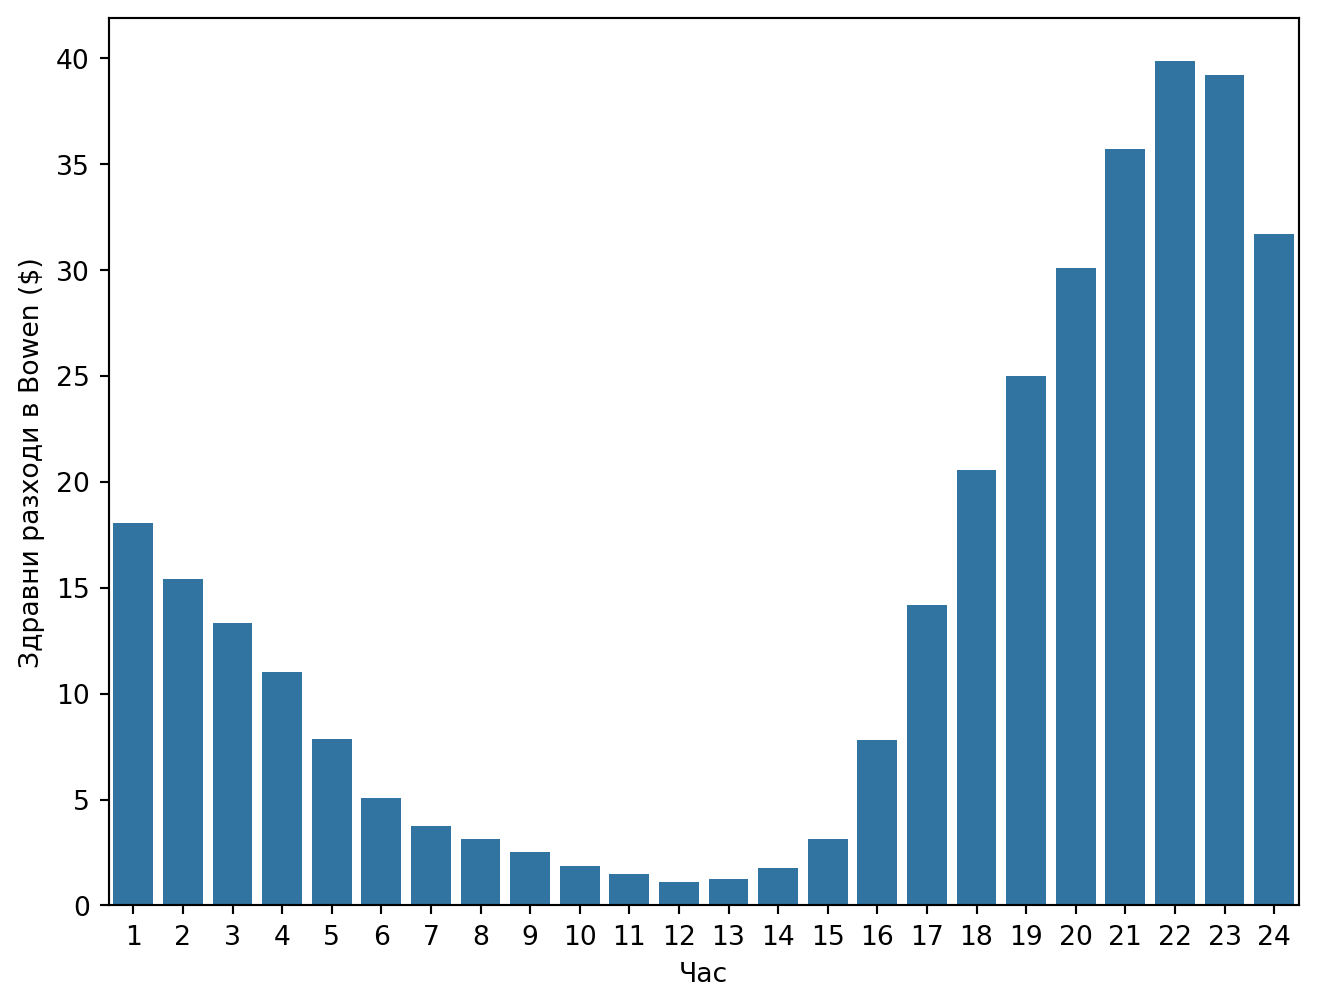

In [8]:
#| label: fig-power-plants-health-costs
#| fig-cap: Здравни разходи за централата Bowen по часове

df_health_costs = pd.read_csv('https://github.com/Gurobi/modeling-examples/blob/master/power_generation/small_plant_data/health_costs.csv?raw=true')

# df_health_costs = pd.read_csv('small_plant_data/health_costs.csv')
a = df_health_costs[(df_health_costs['Year']==2007)&(df_health_costs['Day']==1)].set_index(['Plant','Hour']).to_dict()['Cost'] # Здравни разходи/MWh (централа)
a.update({(i,h): 0 for i in P for h in H if i not in ['Bowen','Jack McDonough','Scherer']})

fig, ax = plt.subplots(figsize=(8, 6))
healthcost_plot = sns.barplot(x=list(range(1,25)), y=[a['Bowen',h] for h in range(1,25)])
healthcost_plot.set_xticklabels(healthcost_plot.get_xticklabels());
healthcost_plot.set(xlabel='Час', ylabel='Здравни разходи в Bowen ($)');
plt.show()

In [9]:
from pathlib import Path
import pandas as pd

output_path = Path("excel/power-plants.xlsx")
output_path.parent.mkdir(parents=True, exist_ok=True)

# Collect all DataFrames currently loaded in the notebook.
dataframes = [
    ("Demand", df_load_curves.sort_values(by=['YEAR', 'MONTH', 'DAY', 'HOUR'])),
    ("Plant Info", df_plant_info),
    ("Fuel Costs", df_fuel_costs),
    ("Operating Costs", df_oper_costs),
    ("Startup Costs", df_startup_costs),
    ("Health Costs", df_health_costs)
]

if not dataframes:
    raise ValueError("No DataFrames found in memory (expected variables like df_*).")

used_sheet_names = set()


def make_sheet_name(name: str) -> str:
    # Excel sheet names are limited to 31 chars and must be unique.
    base = name[:31]
    candidate = base
    idx = 1
    while candidate in used_sheet_names:
        suffix = f"_{idx}"
        candidate = f"{base[:31-len(suffix)]}{suffix}"
        idx += 1
    used_sheet_names.add(candidate)
    return candidate

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    for name, df in sorted(dataframes, key=lambda x: x[0]):
        df.to_excel(writer, sheet_name=make_sheet_name(name), index=False)

print(f"Exported {len(dataframes)} sheets to {output_path}")

Exported 6 sheets to excel/power-plants.xlsx
